## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2


# 안정성 원자료 검증 EDA

`안정성_전체통합_1994_2025.csv` — **원자료가 정상인가**

| 단계 | 질문 |
|---|---|
| 0 | 이 파일에 무엇이 들어있는가 |
| 1 | 제공된 비율을 원항목으로 재현할 수 있는가 |
| 2 | 회계 항등식이 성립하는가 |
| 3 | 경제적으로 불가능한 값이 있는가 |
| 4 | 파생지표(노출도·만기구조·레버리지)가 안정적인가 |
| 5 | 표본 구성이 바뀐 흔적이 있는가 |

## 준비

In [2]:
import pandas as pd, numpy as np, warnings
import matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

for f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
          "Pretendard", "Noto Sans CJK KR", "Noto Sans CJK JP"]:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False)
        mpl.rcParams["font.family"] = f
        print(f"폰트: {f}")
        break
    except Exception:
        continue
mpl.rcParams.update({"axes.unicode_minus": False, "figure.dpi": 100,
                     "axes.grid": True, "grid.alpha": .18,
                     "axes.spines.top": False, "axes.spines.right": False})

INK, WARN, OK, GREY = "#16202B", "#C1682E", "#2E6B5E", "#98A2AA"
PAL = [INK, OK, WARN, "#6B7783", "#A8B2B8"]

def ok_bad(cond, a, b):
    display(Markdown(f"**{'✅ 정상' if cond else '⚠️ 확인필요'}** — {a if cond else b}"))

def paint(df, col="판정", good="정상"):
    return df.style.map(
        lambda x: "background-color:#E4EFEB;color:#1F6152" if x == good
                  else "background-color:#F6E7E4;color:#8E3226", subset=[col])

폰트: Malgun Gothic


In [3]:
PATH = str(INTERIM / "ISTANS 안정성" / "안정성_전체통합_1994_2025.csv")
d = pd.read_csv(PATH, encoding="utf-8-sig")

# 원자료로 직접 합산 — 비율에서 역산하지 않는다
d["총차입금"] = d[["단기차입", "장기차입", "단기사채", "장기사채"]].sum(axis=1)
d["단기부채"] = d["단기차입"] + d["단기사채"]

print(f"{len(d)}행 × {d.shape[1]}열   업종 {d['업종코드'].nunique()}개   "
      f"연도 {d['연도'].min()}~{d['연도'].max()}")
d.head(3)

1280행 × 23열   업종 40개   연도 1994~2025


,업종코드,업종,연도,자산총계,유형자산,유동자산,재고자산,자본총계,이자비용,부채총계,유동부채,비유동부채,단기차입,장기차입,단기사채,장기사채,자본비율,부채비율,유동부채비율,비유동부채비율,차입의존도,총차입금,단기부채
0,I3101,의약,1994,3626.0,961.0,2247.0,409.0,1194.0,143.0,2432.0,1476.0,956.0,650.0,288.0,0.0,428.0,32.9,203.8,123.6,80.1,114.5,1366.0,650.0
1,I3101,의약,1995,4366.0,1238.0,2616.0,474.0,1464.0,180.0,2902.0,1794.0,1108.0,772.0,367.0,0.0,461.0,33.5,198.1,122.5,75.6,109.2,1600.0,772.0
2,I3101,의약,1996,5023.0,1296.0,3092.0,548.0,1647.0,197.0,3376.0,2011.0,1365.0,818.0,459.0,0.0,562.0,32.8,205.0,122.1,82.9,111.6,1839.0,818.0


---
## 0단계 · 기본 구조

In [4]:
cnt = d.groupby("연도").size()
ok_bad(cnt.nunique() == 1, f"연도마다 {cnt.iloc[0]}개 업종 — 완전 균형",
       f"연도별 업종 수 불일치")
ok_bad(d.duplicated(["업종코드", "연도"]).sum() == 0, "업종×연도 중복 없음", "중복 있음")
ok_bad(d.isna().sum().sum() == 0, "결측 없음", f"결측 {d.isna().sum().sum()}건")

num = d.select_dtypes(np.number).drop(columns=["연도"])
display(num.describe().T[["min", "50%", "max"]].round(1)
          .rename(columns={"min": "최소", "50%": "중앙", "max": "최대"}))

**✅ 정상** — 연도마다 40개 업종 — 완전 균형

**✅ 정상** — 업종×연도 중복 없음

**✅ 정상** — 결측 없음

,최소,중앙,최대
자산총계,4.0,9756.0,415154.0
유형자산,0.0,3445.5,165215.0
유동자산,4.0,4032.5,137219.0
재고자산,1.0,1057.0,33273.0
자본총계,-144.0,4755.0,279595.0
이자비용,0.0,156.0,2982.0
부채총계,3.0,4556.5,147344.0
유동부채,3.0,3088.5,111725.0
비유동부채,0.0,1510.0,42045.0
단기차입,0.0,985.0,23612.0


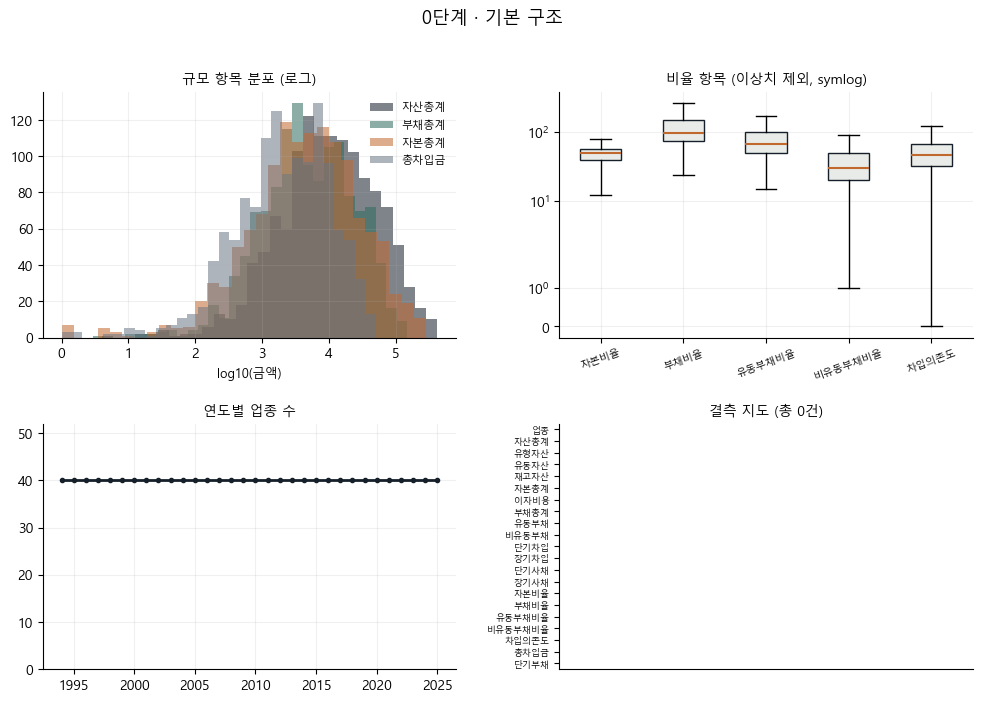

In [5]:
fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

# 규모 항목 로그 분포
ax = fig.add_subplot(gs[0, 0])
for c, col in zip(["자산총계", "부채총계", "자본총계", "총차입금"], PAL):
    ax.hist(np.log10(d[c].clip(lower=1)), bins=30, alpha=.55, label=c, color=col)
ax.set_xlabel("log10(금액)", fontsize=9); ax.legend(frameon=False, fontsize=8)
ax.set_title("규모 항목 분포 (로그)", fontsize=10)

# 비율 항목 박스
ax = fig.add_subplot(gs[0, 1])
rc = ["자본비율", "부채비율", "유동부채비율", "비유동부채비율", "차입의존도"]
ax.boxplot([d[c].dropna() for c in rc], labels=rc, patch_artist=True,
           boxprops=dict(facecolor="#E8EBE7", edgecolor=INK),
           medianprops=dict(color=WARN, lw=1.5), showfliers=False)
ax.set_yscale("symlog"); ax.tick_params(axis="x", labelsize=7.5, rotation=20)
ax.set_title("비율 항목 (이상치 제외, symlog)", fontsize=10)

# 연도별 업종 수
ax = fig.add_subplot(gs[1, 0])
ax.plot(cnt.index, cnt.values, lw=2, color=INK, marker="o", ms=3)
ax.set_ylim(0, cnt.max()*1.3); ax.set_title("연도별 업종 수", fontsize=10)

# 결측 지도
ax = fig.add_subplot(gs[1, 1])
mm = d.set_index(["업종코드", "연도"]).isna().T.astype(int)
ax.imshow(mm, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_yticks(range(len(mm))); ax.set_yticklabels(mm.index, fontsize=6.5)
ax.set_xticks([]); ax.grid(False)
ax.set_title(f"결측 지도 (총 {int(mm.values.sum())}건)", fontsize=10)

plt.suptitle("0단계 · 기본 구조", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 1단계 · 비율 정의 검산

제공된 비율 5개가 어떤 공식으로 만들어졌는지 역산한다.
**분모가 자산총계인지 자본총계인지**가 관건이다.

In [6]:
TOL = 0.15
tests = {
    "자본비율":      [("자본총계/자산총계", d["자본총계"]/d["자산총계"]*100),
                   ("자본총계/부채총계", d["자본총계"]/d["부채총계"]*100)],
    "부채비율":      [("부채총계/자본총계", d["부채총계"]/d["자본총계"]*100),
                   ("부채총계/자산총계", d["부채총계"]/d["자산총계"]*100)],
    "유동부채비율":   [("유동부채/자본총계", d["유동부채"]/d["자본총계"]*100),
                   ("유동부채/자산총계", d["유동부채"]/d["자산총계"]*100)],
    "비유동부채비율": [("비유동부채/자본총계", d["비유동부채"]/d["자본총계"]*100),
                   ("비유동부채/자산총계", d["비유동부채"]/d["자산총계"]*100)],
    "차입의존도":    [("총차입금/자본총계", d["총차입금"]/d["자본총계"]*100),
                   ("총차입금/자산총계", d["총차입금"]/d["자산총계"]*100),
                   ("총차입금/부채총계", d["총차입금"]/d["부채총계"]*100)],
}
rows = []
for col, cands in tests.items():
    for lab, calc in cands:
        diff = (d[col] - calc).abs()
        rows.append({"지표": col, "후보 공식": lab,
                     "일치율(%)": round((diff < TOL).mean()*100, 2),
                     "중앙오차": round(diff.median(), 4)})
R1 = pd.DataFrame(rows)
best = R1.loc[R1.groupby("지표")["일치율(%)"].idxmax()].copy()
best["판정"] = np.where(best["일치율(%)"] > 90, "정상", "확인필요")

display(Markdown("### 확정된 정의"))
display(paint(best[["지표", "후보 공식", "일치율(%)", "판정"]].reset_index(drop=True)))
display(Markdown("### 후보별 전체 결과"))
display(R1)

denom = best["후보 공식"].str.split("/").str[1]
ok_bad((denom == "자본총계").sum() >= 4,
       "비율 대부분이 **자본총계** 기준 — 차입의존도도 자산총계가 아님",
       "분모가 혼재")

### 확정된 정의

,지표,후보 공식,일치율(%),판정
0,부채비율,부채총계/자본총계,90.700000,정상
1,비유동부채비율,비유동부채/자본총계,93.830000,정상
2,유동부채비율,유동부채/자본총계,92.190000,정상
3,자본비율,자본총계/자산총계,97.890000,정상
4,차입의존도,총차입금/자본총계,91.800000,정상


### 후보별 전체 결과

,지표,후보 공식,일치율(%),중앙오차
0,자본비율,자본총계/자산총계,97.89,0.0263
1,자본비율,자본총계/부채총계,0.31,50.7257
2,부채비율,부채총계/자본총계,90.70,0.0297
3,부채비율,부채총계/자산총계,0.00,49.2151
4,유동부채비율,유동부채/자본총계,92.19,0.0290
5,유동부채비율,유동부채/자산총계,0.00,33.5995
6,비유동부채비율,비유동부채/자본총계,93.83,0.0296
7,비유동부채비율,비유동부채/자산총계,0.00,14.9253
8,차입의존도,총차입금/자본총계,91.80,0.0319
9,차입의존도,총차입금/자산총계,0.62,22.9322


**✅ 정상** — 비율 대부분이 **자본총계** 기준 — 차입의존도도 자산총계가 아님

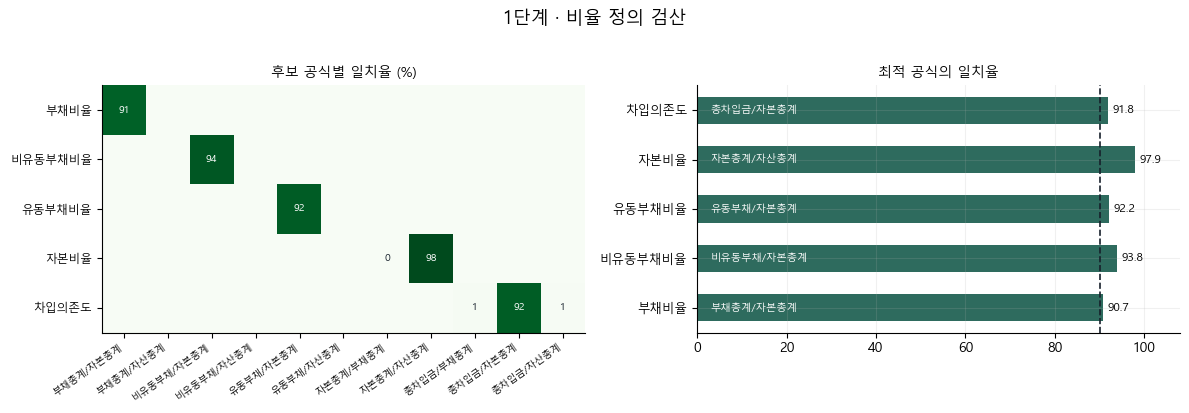

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
piv = R1.pivot(index="지표", columns="후보 공식", values="일치율(%)").fillna(0)
im = ax.imshow(piv, aspect="auto", cmap="Greens", vmin=0, vmax=100)
ax.set_xticks(range(len(piv.columns)))
ax.set_xticklabels(piv.columns, fontsize=7, rotation=35, ha="right")
ax.set_yticks(range(len(piv))); ax.set_yticklabels(piv.index, fontsize=8.5)
for i in range(len(piv)):
    for j in range(len(piv.columns)):
        v = piv.iloc[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                    color="white" if v > 50 else INK)
ax.set_title("후보 공식별 일치율 (%)", fontsize=10); ax.grid(False)

ax = axes[1]
y = np.arange(len(best))
ax.barh(y, best["일치율(%)"], height=.55,
        color=[OK if p == "정상" else WARN for p in best["판정"]])
ax.axvline(90, ls="--", lw=1.2, color=INK)
ax.set_yticks(y); ax.set_yticklabels(best["지표"], fontsize=9)
for i, (v, f_) in enumerate(zip(best["일치율(%)"], best["후보 공식"])):
    ax.text(3, i, f_, va="center", fontsize=7.5, color="white")
    ax.text(v+1, i, f"{v:.1f}", va="center", fontsize=8.5)
ax.set_xlim(0, 108); ax.set_title("최적 공식의 일치율", fontsize=10)

plt.suptitle("1단계 · 비율 정의 검산", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 2단계 · 회계 항등식

In [8]:
checks = [
    ("자산총계 = 부채총계 + 자본총계", d["자산총계"] - d["부채총계"] - d["자본총계"]),
    ("부채총계 = 유동부채 + 비유동부채", d["부채총계"] - d["유동부채"] - d["비유동부채"]),
    ("단기부채 ≤ 총차입금", (d["단기부채"] - d["총차입금"]).clip(lower=0)),
]
rows = []
for lab, r in checks:
    bad = int((r.abs() > 1.5).sum())
    rows.append({"항등식": lab, "위반": bad, "최대오차": round(r.abs().max(), 1),
                 "판정": "정상" if bad == 0 else "확인필요"})
R2 = pd.DataFrame(rows)
display(paint(R2))

viol = d[(d["부채총계"] - d["유동부채"] - d["비유동부채"]).abs() > 1.5]
if len(viol):
    display(Markdown(f"### 부채 항등식 위반 {len(viol)}건 — 연도 분포"))
    display(viol["연도"].value_counts().sort_index().rename("건수").to_frame().T)

,항등식,위반,최대오차,판정
0,자산총계 = 부채총계 + 자본총계,0,1.000000,정상
1,부채총계 = 유동부채 + 비유동부채,37,82.000000,확인필요
2,단기부채 ≤ 총차입금,0,0.000000,정상


### 부채 항등식 위반 37건 — 연도 분포

연도,1997,1998,1999,2011,2019,2020,2021,2022
건수,13,12,2,1,1,4,3,1


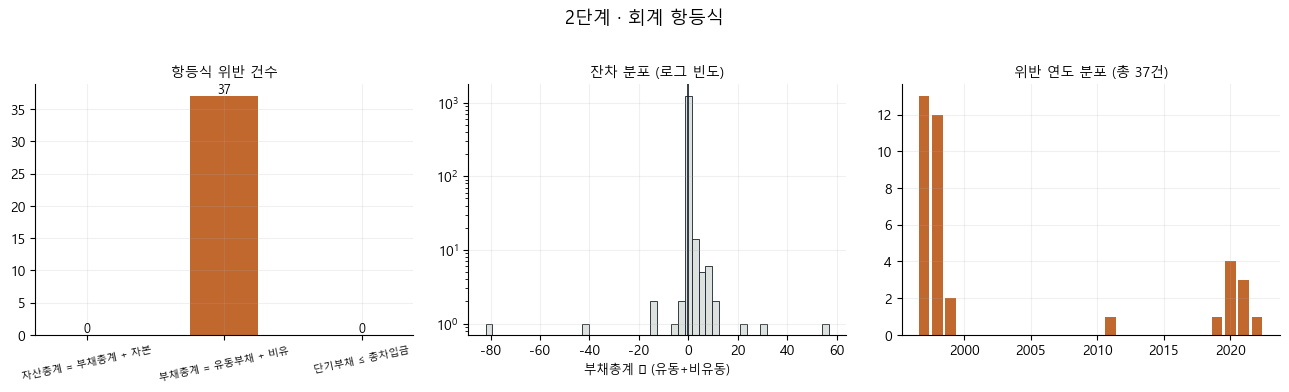

In [9]:
resid = d["부채총계"] - d["유동부채"] - d["비유동부채"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
ax.bar(R2["항등식"].str.slice(0, 16), R2["위반"], width=.5,
       color=[OK if v == 0 else WARN for v in R2["위반"]])
for i, v in enumerate(R2["위반"]):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.tick_params(axis="x", labelsize=7.5, rotation=12)
ax.set_title("항등식 위반 건수", fontsize=10)

ax = axes[1]
ax.hist(resid, bins=50, color="#DDE2DE", edgecolor=INK, linewidth=.6)
ax.axvline(0, color=INK, lw=1.2)
ax.set_yscale("log"); ax.set_xlabel("부채총계 − (유동+비유동)", fontsize=9)
ax.set_title("잔차 분포 (로그 빈도)", fontsize=10)

ax = axes[2]
vy = d.loc[resid.abs() > 1.5, "연도"].value_counts().sort_index()
if len(vy):
    ax.bar(vy.index, vy.values, color=WARN, width=.8)
ax.set_title(f"위반 연도 분포 (총 {int((resid.abs()>1.5).sum())}건)", fontsize=10)

plt.suptitle("2단계 · 회계 항등식", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 3단계 · 부호와 범위

자본총계가 0 이하면 자본총계를 분모로 쓰는 비율이 전부 무의미해진다.

In [10]:
flags = pd.DataFrame([
    ("자본잠식 (자본총계 ≤ 0)", int((d["자본총계"] <= 0).sum())),
    ("저자본 (자본비율 < 10%)", int((d["자본비율"] < 10).sum())),
    ("이자비용 = 0", int((d["이자비용"] == 0).sum())),
    ("총차입금 = 0", int((d["총차입금"] == 0).sum())),
    ("단기사채 = 0", int((d["단기사채"] == 0).sum())),
    ("금액 항목 음수", int((d[["자산총계","부채총계","유동자산","단기차입"]] < 0).sum().sum())),
], columns=["항목", "건수"])
display(flags)

cap = d[d["자본총계"] <= 0]
if len(cap):
    display(Markdown(f"### 자본잠식 {len(cap)}건 — 비율이 음수로 무의미"))
    display(cap[["업종", "연도", "자본총계", "부채비율", "차입의존도"]]
            .round(1).reset_index(drop=True))

ok_bad(len(cap[cap["연도"] >= 2015]) == 0,
       "분석기간(2015~)에는 자본잠식 없음",
       f"분석기간에 {len(cap[cap['연도']>=2015])}건")

,항목,건수
0,자본잠식 (자본총계 ≤ 0),6
1,저자본 (자본비율 < 10%),10
2,이자비용 = 0,2
3,총차입금 = 0,1
4,단기사채 = 0,1001
5,금액 항목 음수,0


### 자본잠식 6건 — 비율이 음수로 무의미

,업종,연도,자본총계,부채비율,차입의존도
0,가전,1998,-6.0,-43356.6,-25381.6
1,가전,1999,-97.0,-3144.8,-1638.6
2,기타 수송장비,1999,-5.0,-4624.4,-2793.0
3,조선,1997,-144.0,-7118.5,-4633.6
4,기타 수송장비,2000,-60.0,-345.0,-200.6
5,기타 수송장비,2001,-50.0,-444.1,-215.5


**✅ 정상** — 분석기간(2015~)에는 자본잠식 없음

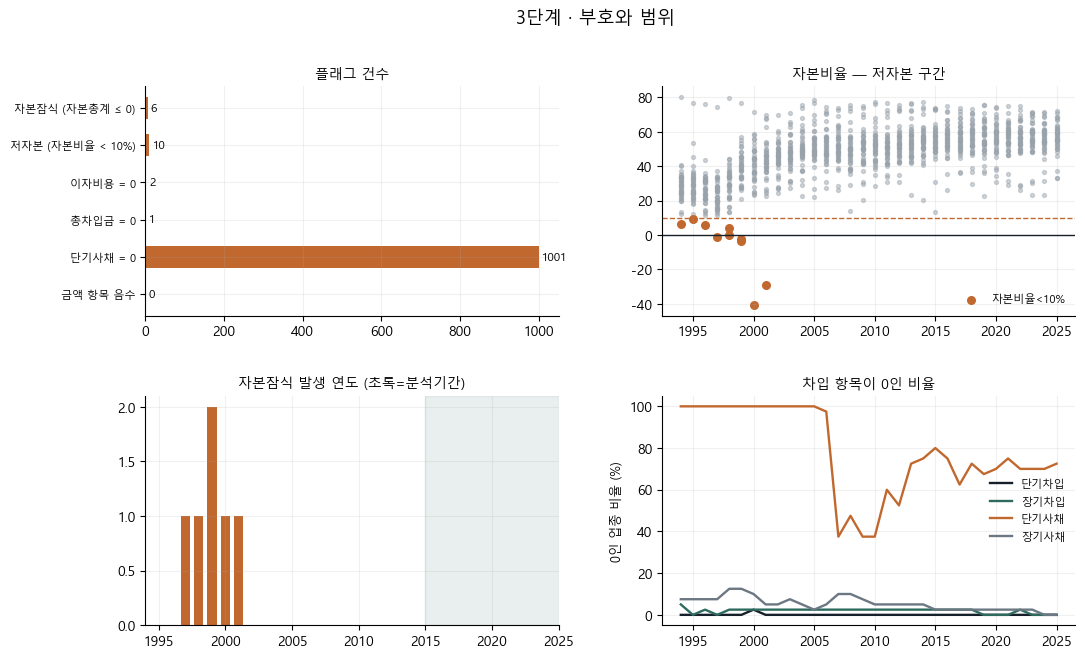

In [11]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

ax = fig.add_subplot(gs[0, 0])
ax.barh(flags["항목"][::-1], flags["건수"][::-1],
        color=[WARN if v > 0 else OK for v in flags["건수"][::-1]], height=.6)
for i, v in enumerate(flags["건수"][::-1]):
    ax.text(v+8, i, str(v), va="center", fontsize=8.5)
ax.set_title("플래그 건수", fontsize=10); ax.tick_params(axis="y", labelsize=8)

ax = fig.add_subplot(gs[0, 1])
ax.scatter(d["연도"], d["자본비율"], s=8, color=GREY, alpha=.45)
bad = d[d["자본비율"] < 10]
ax.scatter(bad["연도"], bad["자본비율"], s=30, color=WARN, label="자본비율<10%")
ax.axhline(10, ls="--", lw=1, color=WARN); ax.axhline(0, color=INK, lw=1)
ax.legend(frameon=False, fontsize=8)
ax.set_title("자본비율 — 저자본 구간", fontsize=10)

ax = fig.add_subplot(gs[1, 0])
yr = d[d["자본총계"] <= 0]["연도"]
if len(yr):
    vc = yr.value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=WARN, width=.7)
ax.set_xlim(d["연도"].min(), d["연도"].max())
ax.axvspan(2015, d["연도"].max(), color=OK, alpha=.1)
ax.set_title("자본잠식 발생 연도 (초록=분석기간)", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
for c, col in zip(["단기차입", "장기차입", "단기사채", "장기사채"], PAL):
    z = d.groupby("연도")[c].apply(lambda s: (s == 0).mean()*100)
    ax.plot(z.index, z.values, lw=1.7, color=col, label=c)
ax.legend(frameon=False, fontsize=8)
ax.set_ylabel("0인 업종 비율 (%)", fontsize=9)
ax.set_title("차입 항목이 0인 비율", fontsize=10)

plt.suptitle("3단계 · 부호와 범위", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 4단계 · 파생지표

노출도를 **만기구조 × 레버리지**로 분해한다.
분모를 잘못 잡으면 두 성분의 관계가 통째로 달라지므로 자산총계 기준으로 통일한다.

$$\text{노출도}=\frac{\text{단기부채}}{\text{자산총계}}
=\underbrace{\frac{\text{단기부채}}{\text{총차입금}}}_{\text{만기구조}}\times
\underbrace{\frac{\text{총차입금}}{\text{자산총계}}}_{\text{레버리지}}$$

In [12]:
EPS = 1e-9
d["노출도"]   = np.where(d["자산총계"] > EPS, d["단기부채"]/d["자산총계"]*100, np.nan)
d["만기구조"] = np.where(d["총차입금"] > EPS, d["단기부채"]/d["총차입금"]*100, np.nan)
d["레버리지"] = np.where(d["자산총계"] > EPS, d["총차입금"]/d["자산총계"]*100, np.nan)
d["현금여력"] = np.where(d["유동부채"] > EPS, d["유동자산"]/d["유동부채"]*100, np.nan)
d["실효차입금리"] = np.where(d["총차입금"] > EPS, d["이자비용"]/d["총차입금"]*100, np.nan)

r = d["노출도"] - d["만기구조"]*d["레버리지"]/100
ok_bad(r.abs().max() < 1e-9, f"분해 항등식 성립 (최대오차 {r.abs().max():.1e})",
       f"항등식 불일치 {r.abs().max():.4f}")

display(d[["노출도", "만기구조", "레버리지", "현금여력", "실효차입금리"]]
          .describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2))

P = (d[d["연도"].isin([2018, 2019, 2020])]
     .groupby(["업종코드", "업종"])[["노출도", "만기구조", "레버리지", "현금여력"]]
     .mean().reset_index())
display(Markdown("### 사전기간(2018~2020) 평균 상관"))
display(P[["노출도", "만기구조", "레버리지", "현금여력"]].corr().round(3))
display(Markdown("> 만기구조는 레버리지를 분모에 갖는 비율이므로 둘의 상관은 해석하지 않는다."))

**✅ 정상** — 분해 항등식 성립 (최대오차 1.4e-14)

,count,mean,std,min,50%,max
노출도,1280.0,12.02,6.43,0.00,11.65,48.41
만기구조,1279.0,50.56,17.34,1.14,52.25,100.00
레버리지,1280.0,24.01,10.19,0.00,22.92,82.43
현금여력,1280.0,129.67,41.25,36.06,124.05,552.52
실효차입금리,1279.0,7.56,5.14,0.00,6.13,63.64


### 사전기간(2018~2020) 평균 상관

,노출도,만기구조,레버리지,현금여력
노출도,1.000,0.636,0.757,-0.534
만기구조,0.636,1.000,0.022,0.027
레버리지,0.757,0.022,1.000,-0.749
현금여력,-0.534,0.027,-0.749,1.000


> 만기구조는 레버리지를 분모에 갖는 비율이므로 둘의 상관은 해석하지 않는다.

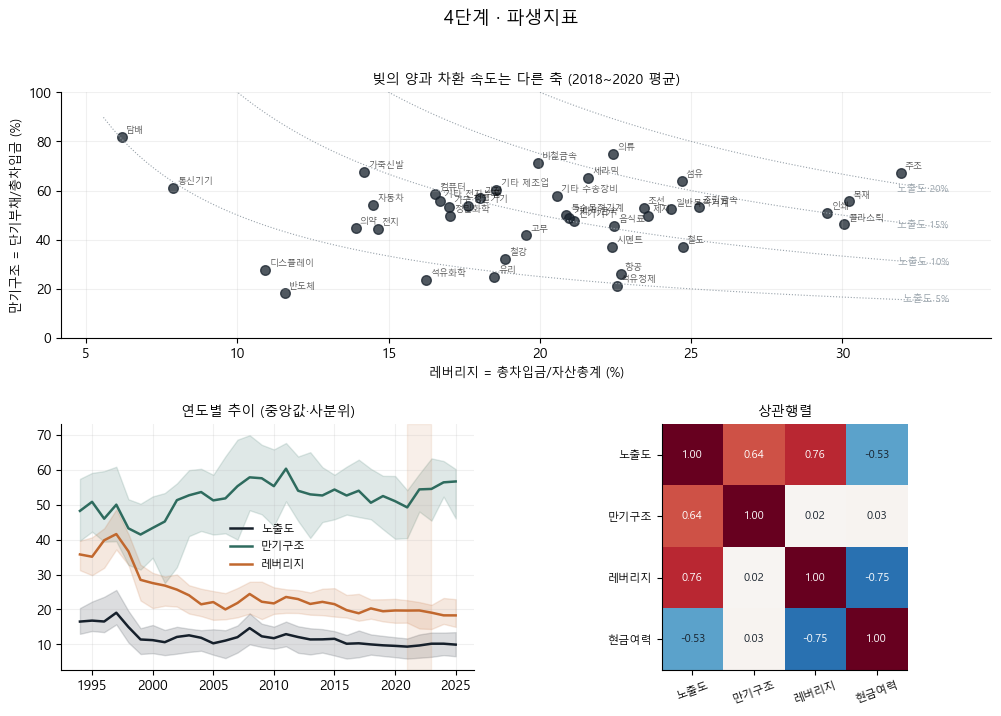

In [13]:
fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

# 산점도 + 노출도 등고선
ax = fig.add_subplot(gs[0, :])
ax.scatter(P["레버리지"], P["만기구조"], s=48, color=INK, alpha=.75)
for _, x in P.iterrows():
    ax.annotate(x["업종"], (x["레버리지"], x["만기구조"]), fontsize=6.5,
                alpha=.65, xytext=(3, 3), textcoords="offset points")
lv = np.linspace(P["레버리지"].min()*.9, P["레버리지"].max()*1.05, 100)
for t in [5, 10, 15, 20]:
    ax.plot(lv, t/lv*100, ls=":", lw=.8, color=GREY)
    ax.annotate(f"노출도 {t}%", (lv[-1], t/lv[-1]*100), fontsize=7,
                color=GREY, ha="right")
ax.set_xlabel("레버리지 = 총차입금/자산총계 (%)", fontsize=9)
ax.set_ylabel("만기구조 = 단기부채/총차입금 (%)", fontsize=9)
ax.set_title("빚의 양과 차환 속도는 다른 축 (2018~2020 평균)", fontsize=10)
ax.set_ylim(0, max(100, P["만기구조"].max()*1.1))

ax = fig.add_subplot(gs[1, 0])
for c, col in zip(["노출도", "만기구조", "레버리지"], PAL):
    g = d.groupby("연도")[c]
    ax.fill_between(g.median().index, g.quantile(.25), g.quantile(.75),
                    alpha=.15, color=col)
    ax.plot(g.median().index, g.median(), lw=1.8, color=col, label=c)
ax.axvspan(2021, 2023, alpha=.1, color=WARN)
ax.legend(frameon=False, fontsize=8)
ax.set_title("연도별 추이 (중앙값·사분위)", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
C = P[["노출도", "만기구조", "레버리지", "현금여력"]].corr()
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(C))); ax.set_xticklabels(C.columns, fontsize=8, rotation=20)
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.index, fontsize=8)
for i in range(len(C)):
    for j in range(len(C)):
        ax.text(j, i, f"{C.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(C.iloc[i,j]) > .6 else INK)
ax.set_title("상관행렬", fontsize=10); ax.grid(False)

plt.suptitle("4단계 · 파생지표", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 5단계 · 표본 연속성

자산총계가 갑자기 몇 배로 뛰면 실제 성장이 아니라
**표본기업 구성이 바뀐 것**일 가능성이 높다.

In [14]:
JUMP = 50
d = d.sort_values(["업종코드", "연도"])
d["자산증가율"] = d.groupby("업종코드")["자산총계"].pct_change()*100

j = d[d["자산증가율"].abs() > JUMP].dropna(subset=["자산증가율"])
display(Markdown(f"**자산총계 ±{JUMP}% 초과: {len(j)}건**"))
display(j.nlargest(10, "자산증가율")[["업종", "연도", "자산총계", "자산증가율"]]
         .round(1).reset_index(drop=True))

recent = j[j["연도"] >= 2015]
display(Markdown(f"### 분석기간(2015~) {len(recent)}건"))
if len(recent):
    display(recent[["업종", "연도", "자산증가율"]].round(1).reset_index(drop=True))
ok_bad(len(recent) <= 5, f"분석기간 급변 {len(recent)}건 — 제한적",
       f"분석기간 급변 {len(recent)}건 — 표본 구성 확인 필요")

**자산총계 ±50% 초과: 29건**

,업종,연도,자산총계,자산증가율
0,철도,1999,937.0,1852.1
1,디스플레이,1998,2651.0,757.9
2,컴퓨터,1995,14.0,250.0
3,기타 수송장비,1996,256.0,161.2
4,기타비금속,2008,2906.0,134.0
5,디스플레이,2012,61595.0,119.7
6,석유정제,2007,46396.0,101.4
7,고무,2003,3488.0,100.9
8,조선,2008,74833.0,85.3
9,컴퓨터,1999,63.0,85.3


### 분석기간(2015~) 3건

,업종,연도,자산증가율
0,컴퓨터,2019,60.3
1,전지,2020,61.1
2,철도,2025,59.8


**✅ 정상** — 분석기간 급변 3건 — 제한적

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


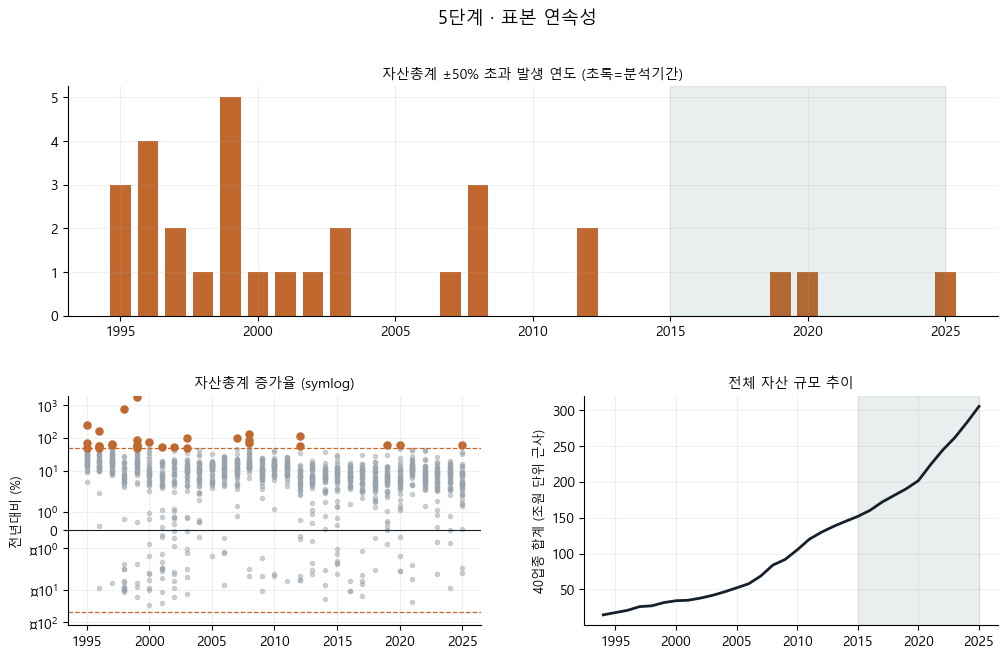

In [15]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

ax = fig.add_subplot(gs[0, :])
vc = j["연도"].value_counts().sort_index()
ax.bar(vc.index, vc.values, color=WARN, width=.75)
ax.axvspan(2015, d["연도"].max(), color=OK, alpha=.1)
ax.set_title(f"자산총계 ±{JUMP}% 초과 발생 연도 (초록=분석기간)", fontsize=10)

ax = fig.add_subplot(gs[1, 0])
ax.scatter(d["연도"], d["자산증가율"], s=9, color=GREY, alpha=.45)
ax.scatter(j["연도"], j["자산증가율"], s=26, color=WARN)
ax.axhline(JUMP, ls="--", lw=.9, color=WARN); ax.axhline(-JUMP, ls="--", lw=.9, color=WARN)
ax.axhline(0, color=INK, lw=.8); ax.set_yscale("symlog")
ax.set_ylabel("전년대비 (%)", fontsize=9)
ax.set_title("자산총계 증가율 (symlog)", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
tot = d.groupby("연도")["자산총계"].sum()
ax.plot(tot.index, tot.values/1e4, lw=2, color=INK)
ax.axvspan(2015, d["연도"].max(), color=OK, alpha=.1)
ax.set_ylabel("40업종 합계 (조원 단위 근사)", fontsize=9)
ax.set_title("전체 자산 규모 추이", fontsize=10)

plt.suptitle("5단계 · 표본 연속성", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 종합

In [16]:
r = d[d["연도"] >= 2015]
S = pd.DataFrame([
    ("0 기본구조", f"{len(d)}행, 40업종×32년 완전균형, 결측 {d.isna().sum().sum()}건", "정상"),
    ("1 정의검산", f"비율 5개 모두 **자본총계** 분모 (차입의존도 포함)", "정상"),
    ("2 항등식", f"자산=부채+자본 위반 0건 / 부채=유동+비유동 위반 "
                f"{int(((d['부채총계']-d['유동부채']-d['비유동부채']).abs()>1.5).sum())}건",
     "확인필요"),
    ("3 부호·범위", f"자본잠식 {int((d['자본총계']<=0).sum())}건 (전부 1997~2001)", "정상"),
    ("4 파생지표", "노출도 = 만기구조 × 레버리지 항등식 성립", "정상"),
    ("5 연속성", f"자산 급변 {len(j)}건, 분석기간 {len(recent)}건", "정상"),
], columns=["단계", "내용", "판정"])
display(paint(S))

display(Markdown(f"""
### 분석기간(2015~2025) 요약
- 관측치 **{len(r)}행**, 결측 **{r.isna().sum().sum()}건**
- 자본잠식 **{int((r['자본총계']<=0).sum())}건**, 이자비용 0 **{int((r['이자비용']==0).sum())}건**

### 처리가 필요한 것
1. **차입의존도를 자산총계 기준으로 오해하지 말 것** — 총차입금은 원자료 합산으로 구한다
2. 자본잠식 6건은 자본총계 분모 비율을 결측 처리 (분석기간 밖)
3. 부채 항등식 위반 37건은 원인 미상 — 유동/비유동 구분을 쓰는 변수에서 주의
4. 자산 급변은 표본 구성 변화로 보이므로 제거하지 말고 한계로 명시
"""))

d.to_csv(INTERIM / "안정성_파생변수_포함.csv", index=False, encoding="utf-8-sig")
print("저장: 안정성_파생변수_포함.csv")

,단계,내용,판정
0,0 기본구조,"1280행, 40업종×32년 완전균형, 결측 42건",정상
1,1 정의검산,비율 5개 모두 **자본총계** 분모 (차입의존도 포함),정상
2,2 항등식,자산=부채+자본 위반 0건 / 부채=유동+비유동 위반 37건,확인필요
3,3 부호·범위,자본잠식 6건 (전부 1997~2001),정상
4,4 파생지표,노출도 = 만기구조 × 레버리지 항등식 성립,정상
5,5 연속성,"자산 급변 29건, 분석기간 3건",정상



### 분석기간(2015~2025) 요약
- 관측치 **440행**, 결측 **0건**
- 자본잠식 **0건**, 이자비용 0 **0건**

### 처리가 필요한 것
1. **차입의존도를 자산총계 기준으로 오해하지 말 것** — 총차입금은 원자료 합산으로 구한다
2. 자본잠식 6건은 자본총계 분모 비율을 결측 처리 (분석기간 밖)
3. 부채 항등식 위반 37건은 원인 미상 — 유동/비유동 구분을 쓰는 변수에서 주의
4. 자산 급변은 표본 구성 변화로 보이므로 제거하지 말고 한계로 명시


저장: 안정성_파생변수_포함.csv
